# Speech Emotion Recognition Baselines: Random Forest and SVM

This notebook trains **traditional ML baseline models** for the speech emotion recognition project using `aggregate_features.csv`.

The CNN/LSTM/Transformer models use mel spectrograms or MFCC sequences, but these baselines use the precomputed aggregate audio statistics such as MFCC means/stds, chroma, spectral features, RMS, pitch, and tempo.

Models included:

- Random Forest baseline
- SVM baseline with feature scaling
- Validation and test evaluation
- Confusion matrices
- Classification reports
- Baseline result summary table


In [1]:
# !pip install scikit-learn pandas numpy matplotlib joblib

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Mount Drive and configure paths

This follows the same project directory style as the LSTM notebook. Place these files in your project folder:

- `aggregate_features.csv`
- `train_split.csv`
- `val_split.csv`
- `test_split.csv`
- optional: `label_map.json`


In [2]:
# Google Colab Drive setup
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/ML2 Final Project"



TRAIN_CSV = os.path.join(PROJECT_DIR, "train_split.csv")
VAL_CSV = os.path.join(PROJECT_DIR, "val_split.csv")
TEST_CSV = os.path.join(PROJECT_DIR, "test_split.csv")
AGG_FEATURES_CSV = os.path.join(PROJECT_DIR, "aggregate_features.csv")
LABEL_MAP_JSON = os.path.join(PROJECT_DIR, "label_map.json")

print("Project directory:", PROJECT_DIR)
print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VAL_CSV)
print("Test CSV:", TEST_CSV)
print("Aggregate features CSV:", AGG_FEATURES_CSV)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/ML2 Final Project
Train CSV: /content/drive/MyDrive/ML2 Final Project/train_split.csv
Validation CSV: /content/drive/MyDrive/ML2 Final Project/val_split.csv
Test CSV: /content/drive/MyDrive/ML2 Final Project/test_split.csv
Aggregate features CSV: /content/drive/MyDrive/ML2 Final Project/aggregate_features.csv


## 2. Load split files and aggregate features

The split CSV files decide which clips belong to train, validation, and test. `aggregate_features.csv` contains the tabular features for each audio clip. We merge them using `file_path`.


In [3]:
train_split = pd.read_csv(TRAIN_CSV)
val_split = pd.read_csv(VAL_CSV)
test_split = pd.read_csv(TEST_CSV)
agg_features = pd.read_csv(AGG_FEATURES_CSV)

print("Train split:", train_split.shape)
print("Validation split:", val_split.shape)
print("Test split:", test_split.shape)
print("Aggregate features:", agg_features.shape)

print("\nTrain columns:")
print(train_split.columns.tolist())

print("\nAggregate feature columns sample:")
print(agg_features.columns[:20].tolist())


Train split: (2982, 9)
Validation split: (630, 9)
Test split: (328, 9)
Aggregate features: (4528, 163)

Train columns:
['file_path', 'emotion', 'speaker_id', 'gender', 'dataset', 'mel_path', 'mel3_path', 'mfcc_path', 'label']

Aggregate feature columns sample:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std']


In [4]:
# Optional label map loading. If label_map.json is unavailable, build names from the split CSVs.
if os.path.exists(LABEL_MAP_JSON):
    with open(LABEL_MAP_JSON, "r") as f:
        label_map = json.load(f)
    # Expected format example: {"angry": 0, "disgust": 1, ...}
    idx_to_emotion = {int(v): k for k, v in label_map.items()}
else:
    combined_labels = pd.concat([
        train_split[["emotion", "label"]],
        val_split[["emotion", "label"]],
        test_split[["emotion", "label"]],
    ], ignore_index=True).drop_duplicates()
    idx_to_emotion = dict(zip(combined_labels["label"].astype(int), combined_labels["emotion"]))

idx_to_emotion = dict(sorted(idx_to_emotion.items()))
class_names = [idx_to_emotion[i] for i in sorted(idx_to_emotion.keys())]
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Class index to emotion name:")
print(idx_to_emotion)


Number of classes: 7
Class index to emotion name:
{0: 'angry', 1: 'disgust', 2: 'fearful', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprised'}


In [5]:
def merge_split_with_features(split_df, agg_df, split_name):
    """Merge a train/val/test split with aggregate features using file_path."""
    needed_cols = ["file_path", "label", "emotion"]
    missing = [c for c in needed_cols if c not in split_df.columns]
    if missing:
        raise ValueError(f"{split_name} split is missing columns: {missing}")

    merged = split_df[needed_cols].merge(
        agg_df,
        on="file_path",
        how="left",
        suffixes=("_split", "_agg")
    )

    missing_feature_rows = merged["mfcc_1_mean"].isna().sum() if "mfcc_1_mean" in merged.columns else 0

    print(f"{split_name}: merged shape = {merged.shape}")
    print(f"{split_name}: rows missing aggregate features = {missing_feature_rows}")

    if missing_feature_rows > 0:
        print("Example missing file paths:")
        print(merged.loc[merged["mfcc_1_mean"].isna(), "file_path"].head())
        raise ValueError(f"Some {split_name} rows did not match aggregate_features.csv. Check file_path formatting.")

    # Use the split emotion as the official label name.
    if "emotion_split" in merged.columns:
        merged["emotion"] = merged["emotion_split"]

    return merged

train_df = merge_split_with_features(train_split, agg_features, "train")
val_df = merge_split_with_features(val_split, agg_features, "validation")
test_df = merge_split_with_features(test_split, agg_features, "test")


train: merged shape = (2982, 165)
train: rows missing aggregate features = 0
validation: merged shape = (630, 165)
validation: rows missing aggregate features = 0
test: merged shape = (328, 165)
test: rows missing aggregate features = 0


## 3. Prepare features and labels

We remove metadata columns and keep only numeric aggregate features as model inputs.


In [6]:
metadata_cols = {
    "clip_id",
    "file_path",
    "emotion",
    "emotion_split",
    "emotion_agg",
    "speaker_id",
    "gender",
    "dataset",
    "label",
}

feature_cols = [
    c for c in train_df.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(train_df[c])
]

print("Number of feature columns:", len(feature_cols))
print("First 15 features:")
print(feature_cols[:15])

X_train = train_df[feature_cols]
y_train = train_df["label"].astype(int)

X_val = val_df[feature_cols]
y_val = val_df["label"].astype(int)

X_test = test_df[feature_cols]
y_test = test_df["label"].astype(int)

print("\nX_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Number of feature columns: 157
First 15 features:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean']

X_train: (2982, 157) y_train: (2982,)
X_val: (630, 157) y_val: (630,)
X_test: (328, 157) y_test: (328,)


In [7]:
# Check class distribution across splits
class_dist = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "val": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).fillna(0).astype(int)

class_dist.index = [idx_to_emotion.get(i, str(i)) for i in class_dist.index]
class_dist


,train,val,test
angry,430,90,47
disgust,439,91,47
fearful,431,91,47
happy,431,91,47
neutral,390,85,46
sad,429,91,47
surprised,432,91,47


## 4. Helper functions for evaluation

The most important baseline metrics are usually **accuracy**, **macro F1**, and **weighted F1**. Macro F1 is useful because it treats all emotion classes equally, even if some classes have fewer examples.


In [8]:
def evaluate_model(model, X, y, split_name, model_name):
    preds = model.predict(X)

    acc = accuracy_score(y, preds)
    macro_f1 = f1_score(y, preds, average="macro")
    weighted_f1 = f1_score(y, preds, average="weighted")

    print(f"\n{model_name} — {split_name} results")
    print("=" * 60)
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(
        y,
        preds,
        labels=sorted(idx_to_emotion.keys()),
        target_names=class_names,
        zero_division=0,
    ))

    return {
        "model": model_name,
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }, preds


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(idx_to_emotion.keys()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 5. Random Forest baseline

Random Forest is a good first baseline because it handles nonlinear relationships and does not require feature scaling.


In [9]:
rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ))
])

rf_model.fit(X_train, y_train)
print("Random Forest training complete.")


Random Forest training complete.



Random Forest — validation results
Accuracy:    0.8984
Macro F1:    0.8983
Weighted F1: 0.8980

Classification report:
              precision    recall  f1-score   support

       angry       0.92      0.86      0.89        90
     disgust       0.88      0.89      0.89        91
     fearful       0.90      0.86      0.88        91
       happy       0.91      0.86      0.88        91
     neutral       0.92      0.94      0.93        85
         sad       0.88      0.95      0.91        91
   surprised       0.90      0.95      0.92        91

    accuracy                           0.90       630
   macro avg       0.90      0.90      0.90       630
weighted avg       0.90      0.90      0.90       630



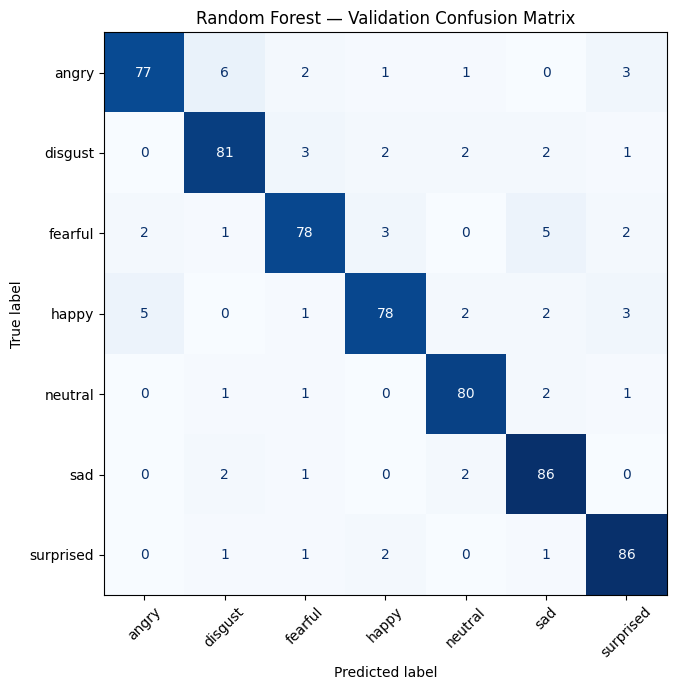


Random Forest — test results
Accuracy:    0.3994
Macro F1:    0.3988
Weighted F1: 0.3985

Classification report:
              precision    recall  f1-score   support

       angry       0.67      0.43      0.52        47
     disgust       0.23      0.55      0.33        47
     fearful       0.55      0.36      0.44        47
       happy       0.50      0.06      0.11        47
     neutral       0.41      0.59      0.48        46
         sad       0.27      0.32      0.29        47
   surprised       0.85      0.49      0.62        47

    accuracy                           0.40       328
   macro avg       0.50      0.40      0.40       328
weighted avg       0.50      0.40      0.40       328



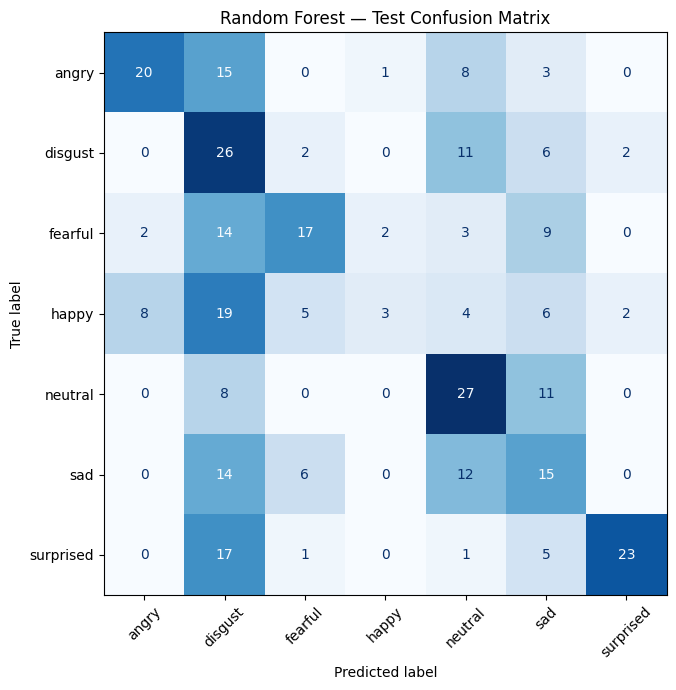

In [10]:
results = []

rf_val_result, rf_val_preds = evaluate_model(rf_model, X_val, y_val, "validation", "Random Forest")
results.append(rf_val_result)
plot_confusion_matrix(y_val, rf_val_preds, "Random Forest — Validation Confusion Matrix")

rf_test_result, rf_test_preds = evaluate_model(rf_model, X_test, y_test, "test", "Random Forest")
results.append(rf_test_result)
plot_confusion_matrix(y_test, rf_test_preds, "Random Forest — Test Confusion Matrix")


The Random Forest baseline performed very well on the validation set, achieving 89.8% accuracy and 89.8% macro F1. The validation confusion matrix shows strong diagonal values, meaning most emotions were classified correctly. However, the test accuracy dropped significantly to 39.9%, showing that the model did not generalize well to unseen test data. The test confusion matrix shows frequent confusion between emotions, especially disgust, neutral, and sad. The happy class had the weakest performance, with very low recall. This large difference between validation and test performance suggests possible overfitting or a distribution difference between the validation and test sets. Since the Random Forest uses aggregate features, it may learn useful but shallow patterns that work on similar data but fail to capture deeper temporal emotion patterns in new speech clips.

Top 20 Random Forest features:


,feature,importance
152,pitch_min,0.025924
151,pitch_std,0.022583
150,pitch_mean,0.021813
3,mfcc_2_std,0.018912
4,mfcc_3_mean,0.017817
55,mfcc_28_std,0.015740
154,pitch_range,0.013950
72,mfcc_37_mean,0.013746
2,mfcc_2_mean,0.013546
35,mfcc_18_std,0.013423


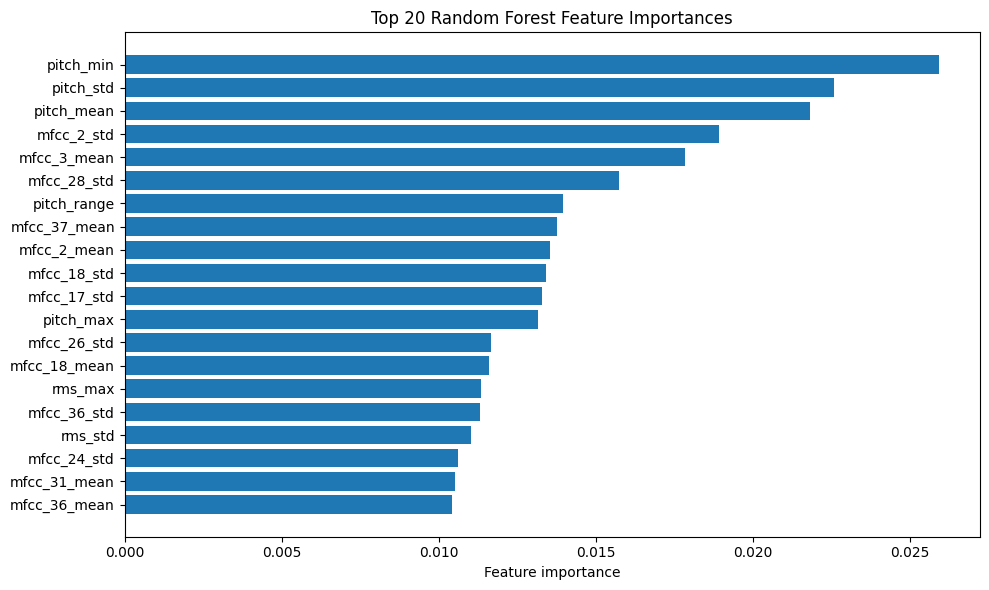

In [11]:
# Optional: feature importance for Random Forest
rf_classifier = rf_model.named_steps["classifier"]
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_classifier.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 20 Random Forest features:")
display(importances.head(20))

plt.figure(figsize=(10, 6))
plt.barh(importances.head(20)["feature"][::-1], importances.head(20)["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


The Random Forest feature importance results show that pitch features were the most important predictors, especially pitch_min, pitch_std, and pitch_mean. This makes sense because emotional speech often changes the speaker’s pitch level and pitch variation. For example, emotions like anger, fear, or surprise may involve higher or more unstable pitch, while sadness or neutral speech may have flatter pitch. Several MFCC features also appear in the top 20, showing that the model uses voice texture and spectral information to classify emotions. RMS features such as rms_max and rms_std also contribute, meaning loudness and energy variation are useful cues. Overall, the feature importance results suggest that the Random Forest baseline is learning meaningful acoustic patterns, but because these are aggregate features, the model may miss detailed temporal changes in speech that deep learning models such as LSTMs, Transformers, or CNNs can capture.

## 6. SVM baseline

SVM usually needs feature scaling because it is sensitive to feature magnitude. This pipeline uses median imputation, standard scaling, and an RBF-kernel SVM.


In [12]:
svm_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
])

svm_model.fit(X_train, y_train)
print("SVM training complete.")


SVM training complete.



SVM RBF — validation results
Accuracy:    0.9175
Macro F1:    0.9176
Weighted F1: 0.9174

Classification report:
              precision    recall  f1-score   support

       angry       0.92      0.90      0.91        90
     disgust       0.90      0.91      0.91        91
     fearful       0.88      0.95      0.91        91
       happy       0.91      0.88      0.89        91
     neutral       0.91      0.98      0.94        85
         sad       0.95      0.90      0.93        91
   surprised       0.95      0.91      0.93        91

    accuracy                           0.92       630
   macro avg       0.92      0.92      0.92       630
weighted avg       0.92      0.92      0.92       630



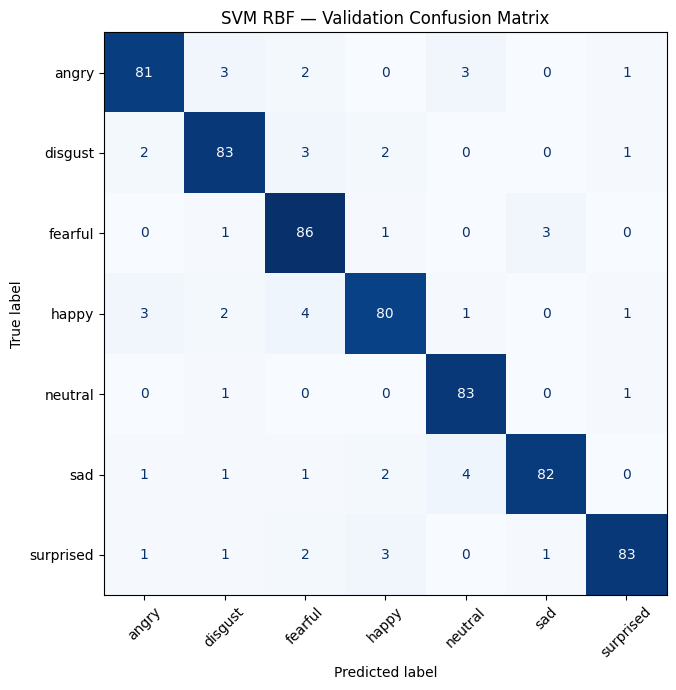


SVM RBF — test results
Accuracy:    0.3720
Macro F1:    0.3770
Weighted F1: 0.3768

Classification report:
              precision    recall  f1-score   support

       angry       0.55      0.36      0.44        47
     disgust       0.30      0.45      0.36        47
     fearful       0.57      0.34      0.43        47
       happy       0.45      0.21      0.29        47
     neutral       0.32      0.67      0.43        46
         sad       0.18      0.23      0.20        47
   surprised       0.89      0.34      0.49        47

    accuracy                           0.37       328
   macro avg       0.47      0.37      0.38       328
weighted avg       0.47      0.37      0.38       328



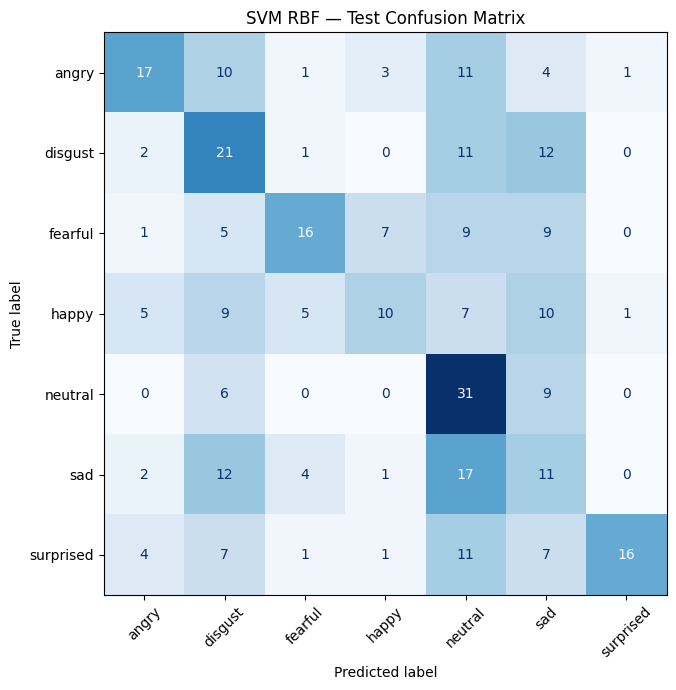

In [13]:
svm_val_result, svm_val_preds = evaluate_model(svm_model, X_val, y_val, "validation", "SVM RBF")
results.append(svm_val_result)
plot_confusion_matrix(y_val, svm_val_preds, "SVM RBF — Validation Confusion Matrix")

svm_test_result, svm_test_preds = evaluate_model(svm_model, X_test, y_test, "test", "SVM RBF")
results.append(svm_test_result)
plot_confusion_matrix(y_test, svm_test_preds, "SVM RBF — Test Confusion Matrix")


The SVM with RBF kernel achieved strong validation performance, with 91.75% accuracy and 91.76% macro F1. The validation confusion matrix shows that most predictions are correct, with high diagonal values across all emotion classes. However, the test accuracy dropped to 37.20%, showing that the model did not generalize well to unseen data. On the test set, the model frequently confused emotions such as sad, neutral, disgust, and happy. This large gap between validation and test performance suggests possible overfitting or a distribution shift between the validation and test sets. Although the RBF SVM can learn nonlinear patterns from the aggregate audio features, these features may not capture enough temporal information from the speech signal. Therefore, sequence-based or spectrogram-based deep learning models may be better suited for capturing emotional changes over time.

## 7. Compare baseline models

Use validation performance to choose which baseline is stronger. Test performance should be reported as the final held-out result.


In [14]:
results_df = pd.DataFrame(results).sort_values(["split", "macro_f1"], ascending=[True, False])
results_df


,model,split,accuracy,macro_f1,weighted_f1
1,Random Forest,test,0.399390,0.398781,0.398527
3,SVM RBF,test,0.371951,0.377015,0.376842
2,SVM RBF,validation,0.917460,0.917635,0.917403
0,Random Forest,validation,0.898413,0.898305,0.898022


Comparing the baseline models, the SVM with RBF kernel achieved the best validation performance with 91.75% accuracy and 91.76% macro F1, while Random Forest achieved 89.84% validation accuracy and 89.83% macro F1. However, on the test set, Random Forest performed slightly better, with 39.94% accuracy compared to 37.20% for SVM RBF. This suggests that although SVM fit the validation data better, Random Forest generalized slightly better to unseen test samples. Overall, both models show a large drop from validation to test performance, which may indicate overfitting or a distribution shift between the validation and test sets. Since these models use aggregate features, they may miss temporal patterns in speech that are important for emotion recognition.